In [3]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torchvision

from torchvision import transforms, datasets
from torch.utils.data import DataLoader

In [4]:
train = datasets.FashionMNIST(
    transform = transforms.ToTensor(),
    root = "data",
    train = True,
    download = True,
    target_transform = None
)

test = datasets.FashionMNIST(
    transform = transforms.ToTensor(),
    root = "data",
    download = True,
    train = False,
    target_transform = None
)

In [5]:
len(train), len(test)

(60000, 10000)

In [6]:
train_loader = DataLoader(train, batch_size = 64, shuffle = True)
test_loader = DataLoader(test, batch_size = 64, shuffle = False)

In [7]:
image, label = next(iter(train_loader))

In [8]:
classnames = train.classes

Text(0.5, 1.0, 'Trouser')

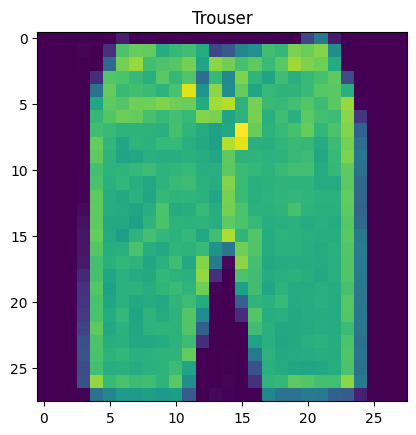

In [9]:
plt.imshow(image[0].squeeze())
plt.title(classnames[label[0]])

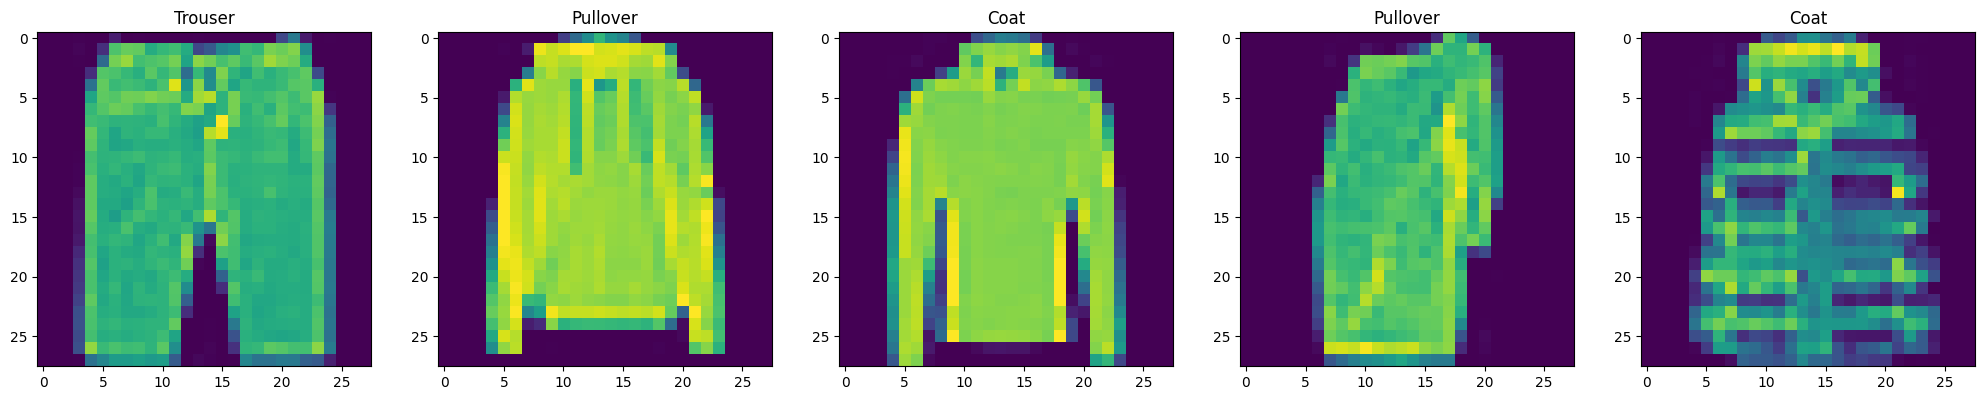

In [10]:
plt.figure(figsize = (25, 20))
for i in range(5):
    # random_idx = torch.randint(0, len(train_loader), size = (1,)).item()
    plt.subplot(1, 5, i + 1)
    plt.imshow(image[i].squeeze())
    plt.title(classnames[label[i]])

In [11]:
class FashionMNISTModel(torch.nn.Module):
    def __init__(self, in_features: int = 784, out_features: int = 10, hidden_units: int = 128, batch_units: int = 64):
        super(FashionMNISTModel, self).__init__()
        self.in_features: int = in_features
        self.out_features: int = out_features
        self.hidden_units: int = hidden_units
        self.batch_units: int = batch_units

        self.network = torch.nn.Sequential(
            torch.nn.Linear(in_features = self.in_features,
                           out_features = self.hidden_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Linear(in_features = self.hidden_units,
                           out_features = self.batch_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Linear(in_features = self.batch_units,
                           out_features = self.out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

In [12]:
device = "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [13]:
torch.manual_seed(42)
torch.mps.manual_seed(42)

In [14]:
model = FashionMNISTModel(in_features = 784).to(device)
model

FashionMNISTModel(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [15]:
def train_test(model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              optimizer: torch.optim.Optimizer,
              accuracy_fn,
              dataset,
              device: torch.device = "cpu"
    ):

    running_loss, running_acc = 0.0, 0.0
    losses, total_accuracy = [], []

    model.train()
    accuracy_fn.reset()

    for idx, (image, target) in enumerate(dataset):
        target_logits = model(image.to(device))
        # train_accuracy = accuracy_fn.update(target, target_logits.argmax(dim = 1).to(device))

        loss = loss_fn(target_logits, target.to(device))
        optimizer.zero_grad()

        loss.backward()
        optimizer.step()

        train_accuracy = accuracy_fn.update(target.to(device), target_logits.argmax(dim = 1))
        running_loss += loss.item()
        running_acc += train_accuracy.item()

    avg_running_loss = running_loss / len(dataset)
    avg_running_acc = running_acc / len(dataset)
    
    losses.append(avg_running_loss)
    total_accuracy.append(avg_running_acc)

    if idx % (0.1 * len(dataset)) == 0:
        print(f"Training Loss: {avg_running_loss} | Training Accuracy: {avg_running_acc}")

    return {avg_running}

In [ ]:
def eval_model(model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              optimizer: torch.optim.Optimizer,
              dataset,
              device: torch.device = "cpu"):
    ...